# ☀️ Solar Power Output Prediction — Simple Linear Regression

## 1. Define the Problem
Predict `solar_power_output` (W) from weather conditions. The target is a continuous number, so this is a **regression** problem. We use **Simple Linear Regression** with one input feature chosen through EDA.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")

## 2. Data Collection and Understanding

In [2]:
df = pd.read_csv("solar_power_output.csv")
df.head()

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
0,19.363503,75.852937,266.619636,5.190818,128.101772
1,33.767858,62.887709,587.710853,4.791819,290.911789
2,28.299849,44.762209,885.651252,0.256421,442.336390
3,24.966462,85.103602,759.002398,3.412478,380.261988
4,13.900466,74.778494,825.905033,3.801956,415.931953


In [3]:
df.shape

(500, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature         500 non-null    float64
 1   humidity            500 non-null    float64
 2   solar_irradiance    500 non-null    float64
 3   wind_speed          500 non-null    float64
 4   solar_power_output  500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


In [5]:
df.describe().round(2)

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
count,500.00,500.00,500.00,500.00,500.00
mean,22.46,58.56,565.80,4.96,283.30
std,7.47,22.84,267.47,2.87,133.84
min,10.13,20.37,104.45,0.03,46.83
25%,16.03,38.33,317.11,2.41,158.41
50%,22.83,57.75,585.76,5.09,290.50
75%,28.90,78.11,799.61,7.37,402.00
max,34.82,99.98,999.47,9.98,502.22


**Insights**
- 500 rows, 5 numeric columns.
- Output ranges from **47 W to 502 W**; irradiance from **104 to 999 W/m²**.

## 3. Exploratory Data Analysis (EDA)
### 3.1 Univariate Analysis — Histogram with KDE
Best for seeing the distribution, spread and skew of each numeric column.

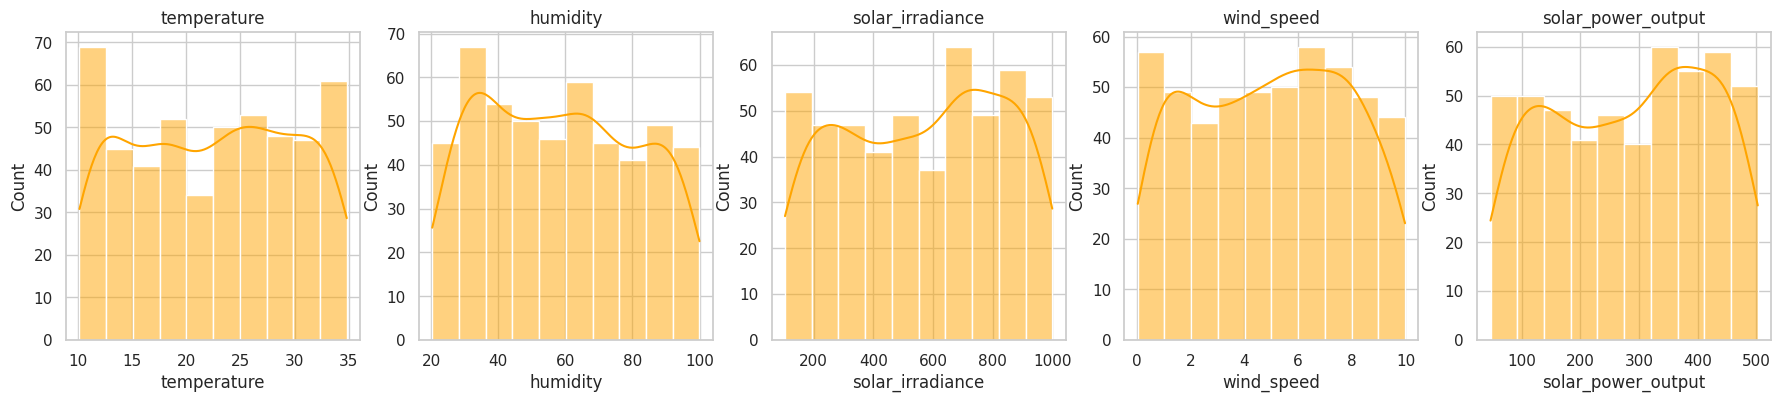

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, df.columns):
    sns.histplot(df[col], kde=True, ax=ax, color="orange")
    ax.set_title(col)
plt.show()

**Insights**
- All columns are **evenly spread** across their range (flat, uniform-like shape) with **no skew**.
- **No outliers** — no isolated bars at the edges.
- Realistic ranges: temperature 10–35 °C, humidity 20–100 %, wind speed 0–10 m/s.

### 3.2 Bivariate Analysis — Scatter Plot with Regression Line
Best for checking the relationship between each feature and the target.

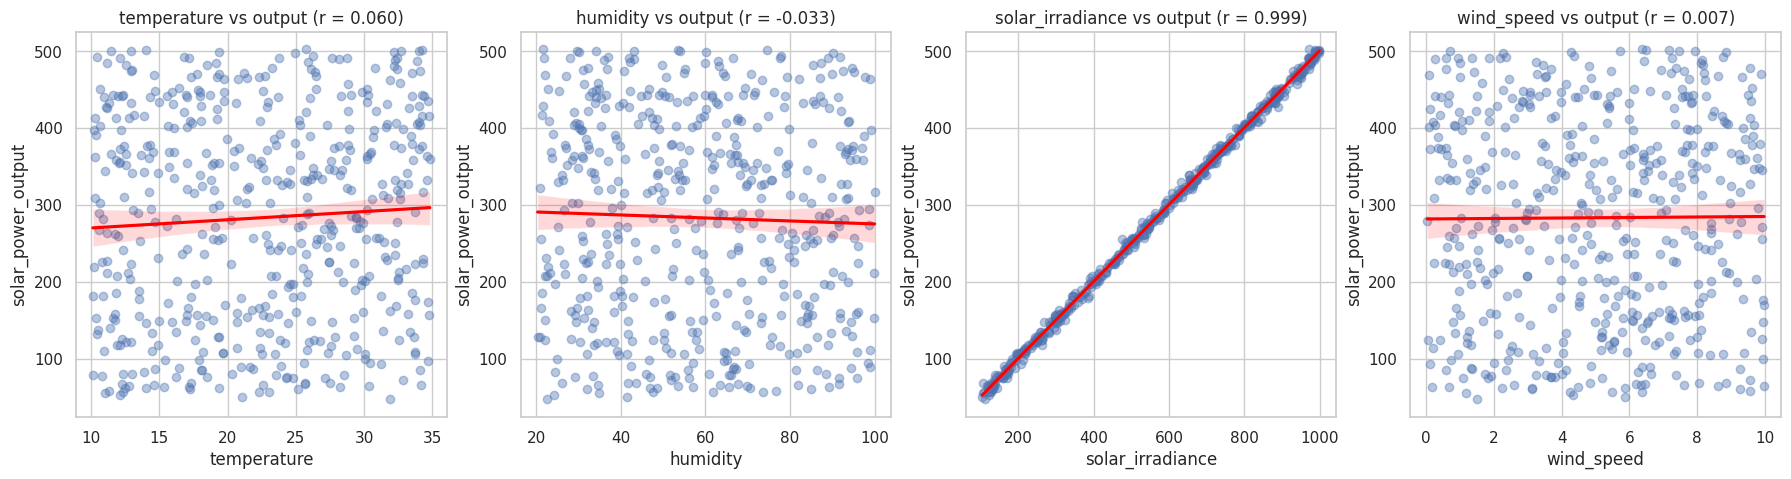

In [7]:
features = ["temperature", "humidity", "solar_irradiance", "wind_speed"]
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, col in zip(axes, features):
    sns.regplot(x=df[col], y=df["solar_power_output"], ax=ax,
                scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
    r = df[col].corr(df["solar_power_output"])
    ax.set_title(f"{col} vs output (r = {r:.3f})")
plt.show()

**Insights**
- **Solar irradiance vs output: r = 0.999**, an almost perfect straight line. More sunlight means more power.
- Output is roughly **half of irradiance** (500 W/m² → ~250 W).
- Temperature, humidity and wind speed show **flat lines** (r ≈ 0), so they have no real effect on output.
- ➡ `solar_irradiance` is the best feature for Simple Linear Regression.

### 3.3 Multivariate Analysis — Correlation Heatmap
Best for comparing relationships between all columns at once.

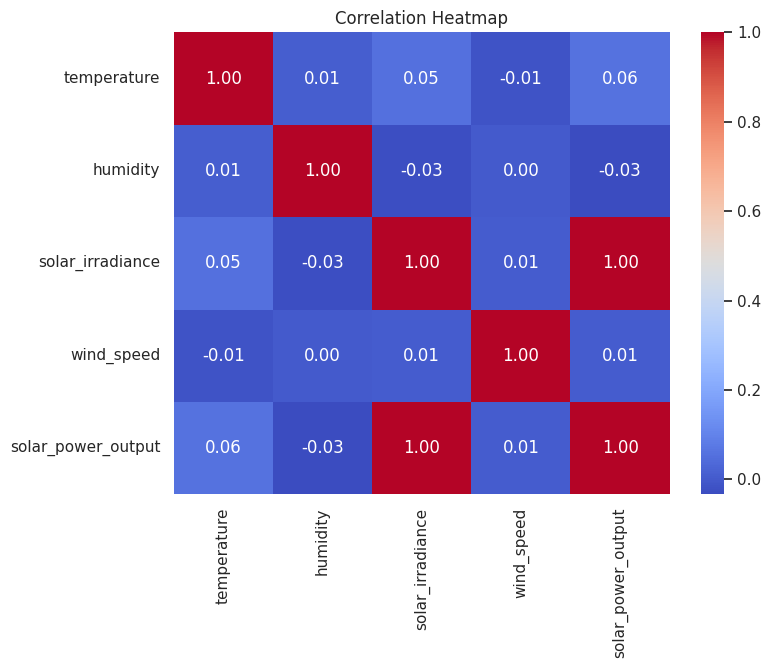

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Insights**
- The only strong relationship is **irradiance ↔ output (1.00)**.
- The features are **not correlated with each other** (all ≈ 0), so there is no multicollinearity.
- This confirms that one feature is enough and Simple Linear Regression is the right choice.

### 📌 EDA Summary
1. Clean, evenly spread data with no outliers.
2. **Solar irradiance** alone drives output (r = 0.999).
3. Other weather features have almost no impact.
4. ➡ **Selected feature: `solar_irradiance`**.

## 4. Data Preprocessing

In [9]:
df.isnull().sum()

temperature           0
humidity              0
solar_irradiance      0
wind_speed            0
solar_power_output    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
X = df[["solar_irradiance"]]
y = df["solar_power_output"]

## 5. Data Splitting

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(400, 1) (100, 1)


## 6. Algorithm Selection
One feature with a straight-line relationship → **Simple Linear Regression**.

## 7. Model Training

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.5005361509109775
Intercept: 0.010596780972093711


Slope ≈ **0.50**: each 1 W/m² of sunlight adds about 0.5 W of output, matching the EDA.

## 8. Model Evaluation (Training Data)

In [14]:
y_train_pred = model.predict(X_train)
print("R2  :", r2_score(y_train, y_train_pred))
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("MSE :", mean_squared_error(y_train, y_train_pred))

R2  : 0.9986590735128839
MAE : 3.868924183319672
MSE : 23.966425673383256


## 9. Final Model Evaluation on Test Data

In [15]:
y_pred = model.predict(X_test)
print("R2  :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))

R2  : 0.9981624336592926
MAE : 4.272564495023546
MSE : 32.33319189996614


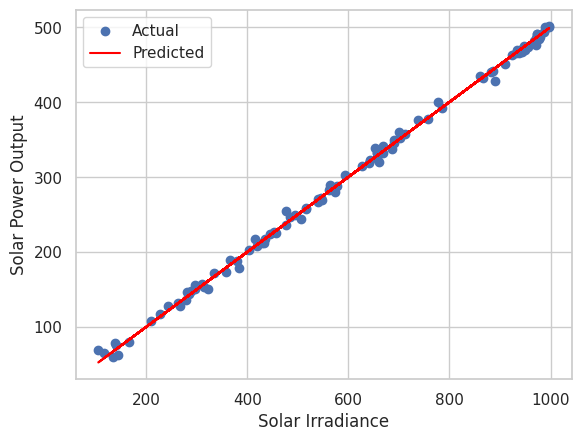

In [16]:
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color="red", label="Predicted")
plt.xlabel("Solar Irradiance")
plt.ylabel("Solar Power Output")
plt.legend()
plt.show()

Test R² ≈ 0.998 and train R² ≈ 0.999: the model fits well and does not overfit.

## 10. Save Model for Deployment

In [17]:
joblib.dump(model, "model.pkl")
print("Model saved")

Model saved
